# Banking Transactions Anomaly Detection using Isolation Forest

This notebook implements a model to detect anomalous banking transactions using an IsolationForest.

**Goals:**
- Load the datasets from `Projects\GenAI_Capstone\Datasets\banking_customers.csv` and `Projects\GenAI_Capstone\Datasets\banking_transactions.csv`
- Do Exploratory Data Analysis (EDA) and feature engineering
- Train an IsolationForest model and score transactions
- Visualize anomalies and save anomalies report

## Environment setup — install dependencies


In [68]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Modules

In [69]:

# imports
import os
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import joblib
import platform


## Config & reproducibility

In [70]:
# Config and reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("./Datasets")
TRANSACTIONS_FILE_NAME = "banking_transactions.csv"
TRANSACTIONS_FILE_PATH = DATA_DIR / TRANSACTIONS_FILE_NAME
CUSTOMER_FILE_NAME = "banking_customers.csv"
CUSTOMER_FILE_PATH = DATA_DIR / CUSTOMER_FILE_NAME
FAST_RUN = True  # Set True to limit rows for quick runs
FAST_NROWS = 5000  # number of rows to load in FAST_RUN mode

print('Data path:', TRANSACTIONS_FILE_PATH , 'and ', CUSTOMER_FILE_PATH)

Data path: Datasets\banking_transactions.csv and  Datasets\banking_customers.csv


## Load Transactions data


In [71]:
# Load CSV
load_kwargs = {"parse_dates": ["timestamp"]}
if FAST_RUN:
    df = pd.read_csv(TRANSACTIONS_FILE_PATH, nrows=FAST_NROWS, **load_kwargs)
else:
    df = pd.read_csv(TRANSACTIONS_FILE_PATH, **load_kwargs)

print('Loaded shape:', df.shape)
df.head()

Loaded shape: (5000, 12)


,txn_id,account_id,timestamp,amount,currency,channel,mcc,merchant,country,state,description,label_fraud
0,T001613,A100267,2024-01-01 02:06:00,2.52,USD,ATM,5921,CAFEBEAN,US,BC,CAFEBEAN BC ATM *REF 58836,0
1,T001569,A100215,2024-01-01 02:28:00,37.62,USD,ECOM,5999,CAFEBEAN,US,BC,CAFEBEAN BC ECOM *REF 93269,0
2,T001510,A100101,2024-01-01 03:07:00,85.43,USD,P2P,4111,GENSTORE,US,ON,GENSTORE ON P2P *REF 54442,0
3,T003040,A100070,2024-01-01 05:39:00,82.01,USD,ECOM,5812,ATM*WITHDRAW,US,QC,ATM*WITHDRAW QC ECOM *REF 55906,0
4,T004569,A100028,2024-01-01 08:45:00,25.73,USD,ECOM,6011,HOTELINN,US,TX,HOTELINN TX ECOM *REF 52938,0


## Exploratory Data Analysis (EDA)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   txn_id       5000 non-null   str           
 1   account_id   5000 non-null   str           
 2   timestamp    5000 non-null   datetime64[us]
 3   amount       5000 non-null   float64       
 4   currency     5000 non-null   str           
 5   channel      5000 non-null   str           
 6   mcc          5000 non-null   int64         
 7   merchant     5000 non-null   str           
 8   country      5000 non-null   str           
 9   state        5000 non-null   str           
 10  description  5000 non-null   str           
 11  label_fraud  5000 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(8)
memory usage: 468.9 KB
None
Missing values:
txn_id         0
account_id     0
timestamp      0
amount         0
currency       0
channel        0
mcc       

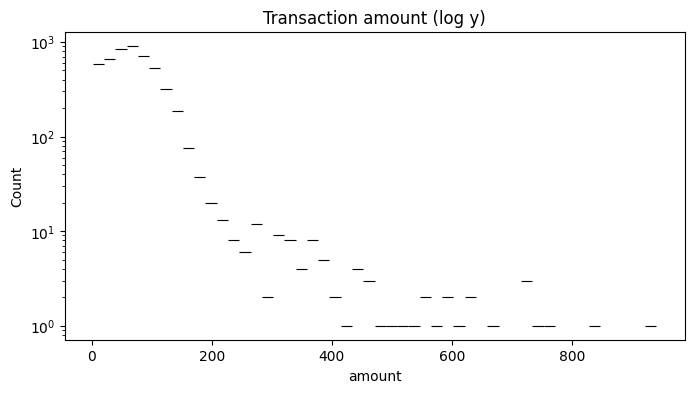

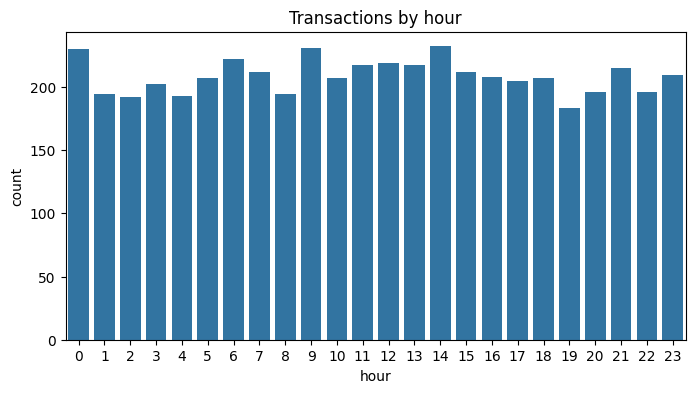

In [72]:
# EDA
print('Info:')
print(df.info())

print('Missing values:')
print(df.isna().sum())

print('Amount summary:')
print(df['amount'].describe())

# time range
print('Time range:')
print(df['timestamp'].min(), '->', df['timestamp'].max())

# top merchants and mcc
print('Top merchants:')
print(df['merchant'].value_counts().head(10))
print('Top mcc:')
print(df['mcc'].value_counts().head(10))

# plots
plt.figure(figsize=(8,4))
sns.histplot(df['amount'], bins=50, log_scale=(False, True))
plt.title('Transaction amount (log y)')
plt.show()

plt.figure(figsize=(8,4))
df['hour'] = df['timestamp'].dt.hour
sns.countplot(x='hour', data=df, color='tab:blue')
plt.title('Transactions by hour')
plt.show()

## Preprocessing & feature engineering of Trancations data

In [73]:
# Preprocessing & features
df_proc = df.copy()
# amount log transform
df_proc['amount_log'] = np.log1p(df_proc['amount'].astype(float))
# time features (hour already created)
df_proc['dayofweek'] = df_proc['timestamp'].dt.dayofweek
df_proc['is_weekend'] = df_proc['dayofweek'].isin([5,6]).astype(int)

# frequency encoding for merchant, mcc, country, state( frequency encoding on categorical columns)
for col in ['merchant','mcc','country','state','channel']:
    freq = df_proc[col].value_counts(dropna=True).to_dict()
    df_proc[f'{col}_freq'] = df_proc[col].map(freq).fillna(0).astype(int)

# select features for model

feature_cols = ['amount_log','hour','dayofweek','is_weekend',
                'merchant_freq','mcc_freq','country_freq','state_freq','channel_freq']

df_proc = df_proc.dropna(subset=['amount'])
X = df_proc[feature_cols].astype(float)

print('Feature matrix shape:', X.shape)
X.head()

Feature matrix shape: (5000, 9)


,amount_log,hour,dayofweek,is_weekend,merchant_freq,mcc_freq,country_freq,state_freq,channel_freq
0,1.258461,2.0,0.0,0.0,556.0,554.0,4100.0,955.0,265.0
1,3.653770,2.0,0.0,0.0,556.0,577.0,4100.0,955.0,2231.0
2,4.459335,3.0,0.0,0.0,538.0,514.0,4100.0,767.0,239.0
3,4.418961,5.0,0.0,0.0,549.0,563.0,4100.0,688.0,2231.0
4,3.285787,8.0,0.0,0.0,534.0,531.0,4100.0,708.0,2231.0


## Load Customer Data and Join Transactions and cUstomers data on account Id

In [74]:
# Load customer data
df_customers = pd.read_csv(CUSTOMER_FILE_PATH)
print(f"Customers loaded: {len(df_customers)}")
print(f"Customer dataset Columns: {df_customers.columns.tolist()}")

# Merge customer data with transactions on account_id
df_merged = df.merge(df_customers, on='account_id', how='left')
print(f"Merged shape: {df_merged.shape}")
print(f"Merged columns: {df_merged.columns.tolist()}")

# Check for missing values
print(f"Missing account_ids: {df_merged['account_id'].isna().sum()}")
print(f"Missing customer data: {df_merged['tenure_months'].isna().sum()}")

df_merged.head()

Customers loaded: 300
Customer dataset Columns: ['account_id', 'country', 'state', 'age', 'tenure_months', 'segment']
Merged shape: (5000, 18)
Merged columns: ['txn_id', 'account_id', 'timestamp', 'amount', 'currency', 'channel', 'mcc', 'merchant', 'country_x', 'state_x', 'description', 'label_fraud', 'hour', 'country_y', 'state_y', 'age', 'tenure_months', 'segment']
Missing account_ids: 0
Missing customer data: 0


,txn_id,account_id,timestamp,amount,currency,channel,mcc,merchant,country_x,state_x,description,label_fraud,hour,country_y,state_y,age,tenure_months,segment
0,T001613,A100267,2024-01-01 02:06:00,2.52,USD,ATM,5921,CAFEBEAN,US,BC,CAFEBEAN BC ATM *REF 58836,0,2,US,BC,41,71,student
1,T001569,A100215,2024-01-01 02:28:00,37.62,USD,ECOM,5999,CAFEBEAN,US,BC,CAFEBEAN BC ECOM *REF 93269,0,2,US,BC,46,141,retail
2,T001510,A100101,2024-01-01 03:07:00,85.43,USD,P2P,4111,GENSTORE,US,ON,GENSTORE ON P2P *REF 54442,0,3,US,ON,60,74,retail
3,T003040,A100070,2024-01-01 05:39:00,82.01,USD,ECOM,5812,ATM*WITHDRAW,US,QC,ATM*WITHDRAW QC ECOM *REF 55906,0,5,US,QC,35,68,retail
4,T004569,A100028,2024-01-01 08:45:00,25.73,USD,ECOM,6011,HOTELINN,US,TX,HOTELINN TX ECOM *REF 52938,0,8,US,TX,42,30,student


## Feature Engineer/PrePorocess Merged Data

In [75]:
# Engineer behavioral features from customer data
df_enriched = df_proc.copy()

# Add customer features from merged data
customer_features = df_merged[['account_id', 'age', 'tenure_months', 'segment']].drop_duplicates(subset=['account_id'])
df_enriched = df_enriched.merge(customer_features, on='account_id', how='left')

# 1. Account age risk: new accounts (tenure < 6 months) are higher risk
df_enriched['new_account'] = (df_enriched['tenure_months'] < 6).astype(int)
df_enriched['account_tenure_days'] = df_enriched['tenure_months'] * 30

# 2. Segment encoding (categorical to numerical)
segment_risk = {'student': 3, 'retail': 1, 'smallbiz': 2, 'affluent': 0}
df_enriched['segment_risk'] = df_enriched['segment'].map(segment_risk).fillna(1)

# 3. Age-based risk
df_enriched['age_young_flag'] = (df_enriched['age'] < 25).astype(int)
df_enriched['age_elderly_flag'] = (df_enriched['age'] > 65).astype(int)

# 4. Per-customer velocity and patterns (aggregate by account_id)
txn_velocity = df_enriched.groupby('account_id').agg({
    'txn_id': 'count',  # total transactions
    'amount': ['mean', 'std', 'max'],
    'merchant': 'nunique'  # unique merchants
}).reset_index()

txn_velocity.columns = ['account_id', 'txn_count', 'avg_amount', 'std_amount', 'max_amount', 'unique_merchants']
txn_velocity['amount_std'] = txn_velocity['std_amount'].fillna(0)  # fill NaN for accounts with 1 transaction
txn_velocity['merchant_diversity'] = txn_velocity['unique_merchants'] / (txn_velocity['txn_count'] + 1)

# Merge velocity features back
df_enriched = df_enriched.merge(txn_velocity[['account_id', 'avg_amount', 'unique_merchants', 'merchant_diversity']], 
                                 on='account_id', how='left')

# 5. Amount deviation: how much does this transaction deviate from customer average?
df_enriched['amount_deviation'] = (df_enriched['amount'] - df_enriched['avg_amount']).abs()
df_enriched['amount_ratio'] = df_enriched['amount'] / (df_enriched['avg_amount'] + 1)  # avoid division by zero

# 6. Geo features: same-country transactions or cross-country
df_enriched['same_country'] = (df_enriched['country'] == df_enriched['country']).astype(int)  # will need state/country mapping
print(" Behavioral features engineered!\n\nNew features added:,  new_account (tenure < 6 months),  account_tenure_days,  segment_risk (0=affluent, 1=retail, 2=smallbiz, 3=student),  age_young_flag, age_elderly_flag,  avg_amount (customer average),  unique_merchants,  merchant_diversity,  amount_deviation (|txn  customer_avg|) and  amount_ratio (txn / customer_avg)")
df_enriched[['amount', 'avg_amount', 'amount_deviation', 'amount_ratio', 'new_account', 'segment_risk']].head(10)

 Behavioral features engineered!

New features added:,  new_account (tenure < 6 months),  account_tenure_days,  segment_risk (0=affluent, 1=retail, 2=smallbiz, 3=student),  age_young_flag, age_elderly_flag,  avg_amount (customer average),  unique_merchants,  merchant_diversity,  amount_deviation (|txn  customer_avg|) and  amount_ratio (txn / customer_avg)


,amount,avg_amount,amount_deviation,amount_ratio,new_account,segment_risk
0,2.52,54.206923,51.686923,0.045646,0,3
1,37.62,52.624762,15.004762,0.701542,0,1
2,85.43,63.413636,22.016364,1.326272,0,1
3,82.01,85.942500,3.932500,0.943267,0,1
4,25.73,47.617500,21.887500,0.529233,0,3
5,76.58,87.329000,10.749000,0.866986,0,1
6,42.59,68.989375,26.399375,0.608521,0,1
7,90.84,72.665000,18.175000,1.233150,0,3
8,72.35,91.060000,18.710000,0.785900,0,0
9,128.42,72.533333,55.886667,1.746419,0,2


## Train / Test Split with Enhanced Features

In [76]:
# Prepare enhanced feature set (transaction + customer features)
enhanced_features = ['amount_log','hour','dayofweek','is_weekend',
                     'merchant_freq','mcc_freq','country_freq','state_freq','channel_freq',
                     'new_account', 'account_tenure_days', 'segment_risk', 
                     'age_young_flag', 'age_elderly_flag', 
                     'avg_amount', 'unique_merchants', 'merchant_diversity',
                     'amount_deviation', 'amount_ratio']

X_enhanced = df_enriched[enhanced_features].astype(float)
X_enhanced = X_enhanced.fillna(0)

# Train / test split (80% train, 20% test)
X_train, X_test = train_test_split(X_enhanced, test_size=0.2, random_state=RANDOM_SEED)
df_train = df_enriched.loc[X_train.index]
df_test = df_enriched.loc[X_test.index]

# Create y_train and y_test (for evaluation)
if 'label_fraud' in df_enriched.columns:
    y_train = df_enriched.loc[X_train.index, 'label_fraud'].astype(int)
    y_test = df_enriched.loc[X_test.index, 'label_fraud'].astype(int)
    print('Train/Test split with ENHANCED features:')
    print(f'  X_train: {X_train.shape}, X_test: {X_test.shape}')
    print(f'  y_train: {y_train.shape}, y_test: {y_test.shape}')
    print(f'  Fraud cases -> train: {y_train.sum()}, test: {y_test.sum()}')
else:
    y_train = None
    y_test = None
    print(f'Train/Test split: X_train {X_train.shape}, X_test {X_test.shape}')
    print('No label_fraud column found')

Train/Test split with ENHANCED features:
  X_train: (4000, 19), X_test: (1000, 19)
  y_train: (4000,), y_test: (1000,)
  Fraud cases -> train: 121, test: 22


## Train IsolationForest model

In [77]:
# Train IsolationForest with ENHANCED features (transaction + customer data)
contamination = 0.05  # expect ~5% anomalies
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('iforest', IsolationForest(n_estimators=200, max_samples='auto', 
                                contamination=contamination,
                                random_state=RANDOM_SEED, n_jobs=-1))
])

print("Training IsolationForest with 19 features (9 transaction + 10 customer/behavioral)...")
start = time.time()
clf_pipeline.fit(X_train)
end = time.time()
print(f'✓ Trained in {end-start:.2f}s')
print(f'  Features used: {len(enhanced_features)}')
print(f'  Training samples: {X_train.shape[0]}')

Training IsolationForest with 19 features (9 transaction + 10 customer/behavioral)...
✓ Trained in 0.43s
  Features used: 19
  Training samples: 4000


## Score transactions and attach anomaly flags

In [78]:
# Score all transactions with the trained model
enhanced_features = [
    'amount_log', 'hour', 'dayofweek', 'is_weekend',
    'merchant_freq', 'mcc_freq', 'country_freq', 'state_freq', 'channel_freq',
    'new_account', 'account_tenure_days', 'segment_risk',
    'age_young_flag', 'age_elderly_flag', 'avg_amount', 'unique_merchants',
    'merchant_diversity', 'amount_deviation', 'amount_ratio'
]

X_all = df_enriched[enhanced_features].astype(float).fillna(0)

# Get decision function scores
decision_scores = clf_pipeline.named_steps['iforest'].decision_function(X_all)
anomaly_scores = -decision_scores  # Convert to positive anomaly scores (higher = more anomalous)

# Use custom threshold: mark top contamination% as anomalies
contamination_rate = 0.05
threshold = np.percentile(anomaly_scores, 100 * (1 - contamination_rate))
anomaly_flag = (anomaly_scores >= threshold).astype(int)

# Attach scores and flags to enriched data
df_enriched['anomaly_score'] = anomaly_scores
df_enriched['anomaly_flag'] = anomaly_flag

print(f'Scoring complete!')
print(f'Total transactions: {len(df_enriched)}')
print(f'Anomalies detected: {anomaly_flag.sum()} ({100*anomaly_flag.sum()/len(df_enriched):.1f}%)')
print(f'Anomaly score threshold: {threshold:.4f}')
print(f'Score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]')

Scoring complete!
Total transactions: 5000
Anomalies detected: 250 (5.0%)
Anomaly score threshold: 0.0821
Score range: [0.0049, 0.1151]


## Evaluation & visualization

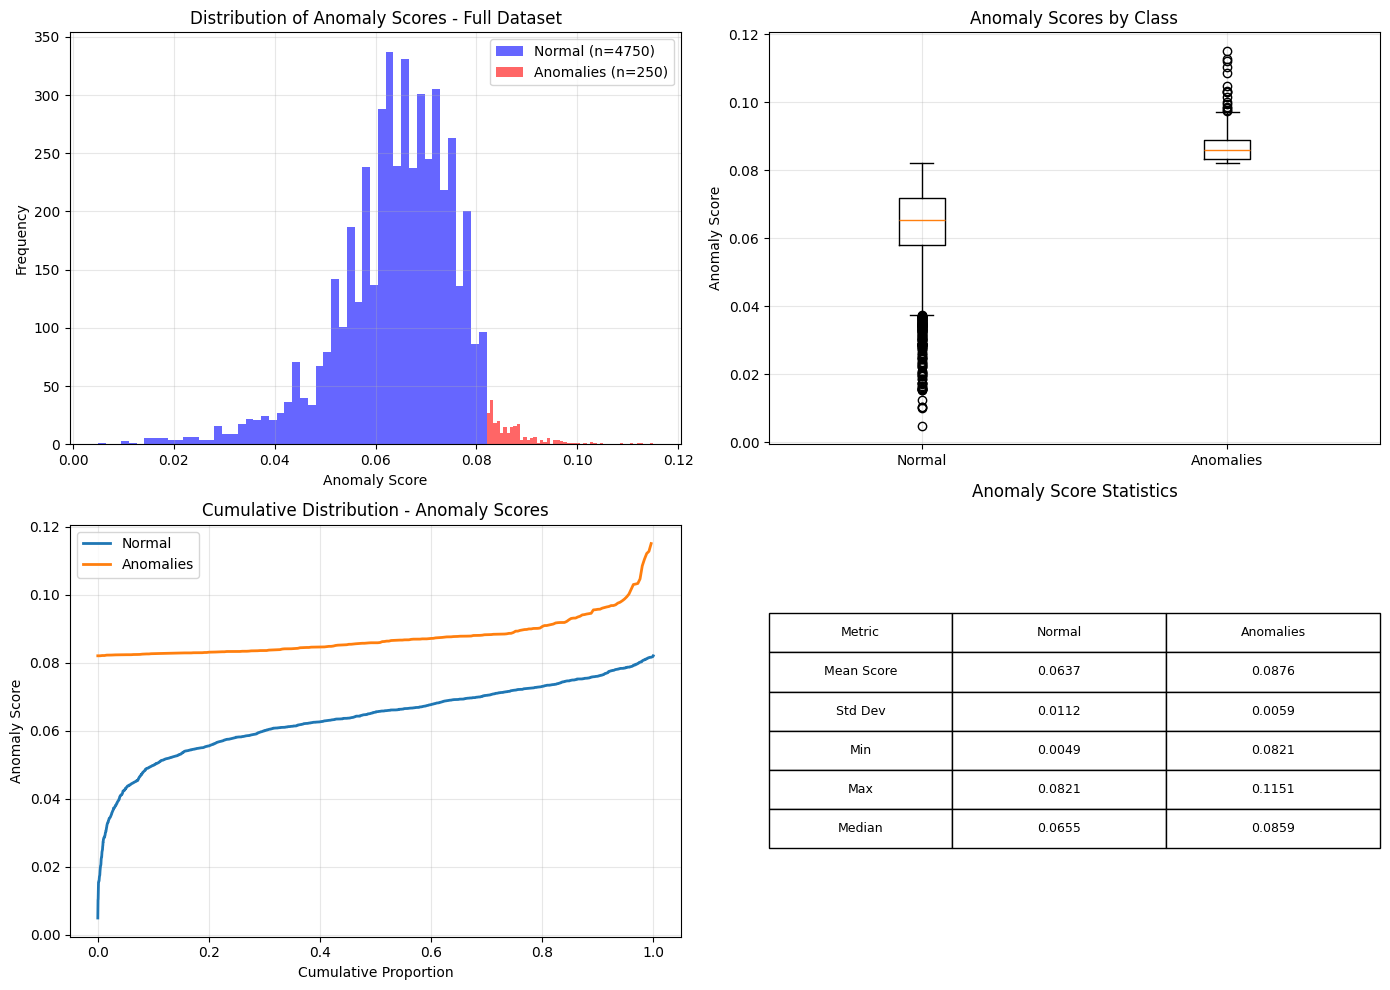

Anomaly Score Analysis Complete


In [79]:
# Visualize Anomaly Scores Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for anomaly score analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of anomaly scores for full dataset
ax = axes[0, 0]
normal = df_enriched[df_enriched['anomaly_flag'] == 0]['anomaly_score']
anomalies = df_enriched[df_enriched['anomaly_flag'] == 1]['anomaly_score']
ax.hist(normal, bins=50, alpha=0.6, label=f'Normal (n={len(normal)})', color='blue')
ax.hist(anomalies, bins=50, alpha=0.6, label=f'Anomalies (n={len(anomalies)})', color='red')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Anomaly Scores - Full Dataset')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Box plot of anomaly scores
ax = axes[0, 1]
ax.boxplot([normal, anomalies], labels=['Normal', 'Anomalies'])
ax.set_ylabel('Anomaly Score')
ax.set_title('Anomaly Scores by Class')
ax.grid(True, alpha=0.3)

# 3. Cumulative distribution
ax = axes[1, 0]
normal_sorted = np.sort(normal)
anomalies_sorted = np.sort(anomalies)
ax.plot(np.arange(len(normal_sorted))/len(normal_sorted), normal_sorted, label='Normal', linewidth=2)
ax.plot(np.arange(len(anomalies_sorted))/len(anomalies_sorted), anomalies_sorted, label='Anomalies', linewidth=2)
ax.set_xlabel('Cumulative Proportion')
ax.set_ylabel('Anomaly Score')
ax.set_title('Cumulative Distribution - Anomaly Scores')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Score statistics table
ax = axes[1, 1]
ax.axis('off')
stats_data = [
    ['Metric', 'Normal', 'Anomalies'],
    ['Mean Score', f'{normal.mean():.4f}', f'{anomalies.mean():.4f}'],
    ['Std Dev', f'{normal.std():.4f}', f'{anomalies.std():.4f}'],
    ['Min', f'{normal.min():.4f}', f'{anomalies.min():.4f}'],
    ['Max', f'{normal.max():.4f}', f'{anomalies.max():.4f}'],
    ['Median', f'{normal.median():.4f}', f'{anomalies.median():.4f}'],
]
table = ax.table(cellText=stats_data, cellLoc='center', loc='center', 
                colWidths=[0.3, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
ax.set_title('Anomaly Score Statistics', pad=20)

plt.tight_layout()
plt.show()

print(f'Anomaly Score Analysis Complete')

## Model Testing & Evaluation on Test Set

In [86]:
# Evaluate model performance on test set
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Get predictions on test set
y_pred_test = clf_pipeline.named_steps['iforest'].predict(X_test)
y_anomaly = (y_pred_test == -1).astype(int)  # Convert to binary: 0=normal, 1=anomaly
test_scores = -clf_pipeline.decision_function(X_test)

# Evaluation metrics (uses actual fraud labels from y_test)
roc_auc = roc_auc_score(y_test, test_scores)
precision = precision_score(y_test, y_anomaly, zero_division=0)
recall = recall_score(y_test, y_anomaly, zero_division=0)
f1 = f1_score(y_test, y_anomaly, zero_division=0)

print('='*50)
print('TEST SET EVALUATION METRICS')
print('='*50)
print(f'ROC AUC:   {roc_auc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print('='*50)

TEST SET EVALUATION METRICS
ROC AUC:   0.9599
Precision: 0.0220
Recall:    1.0000
F1 Score:  0.0431


### Confusion Matrix 

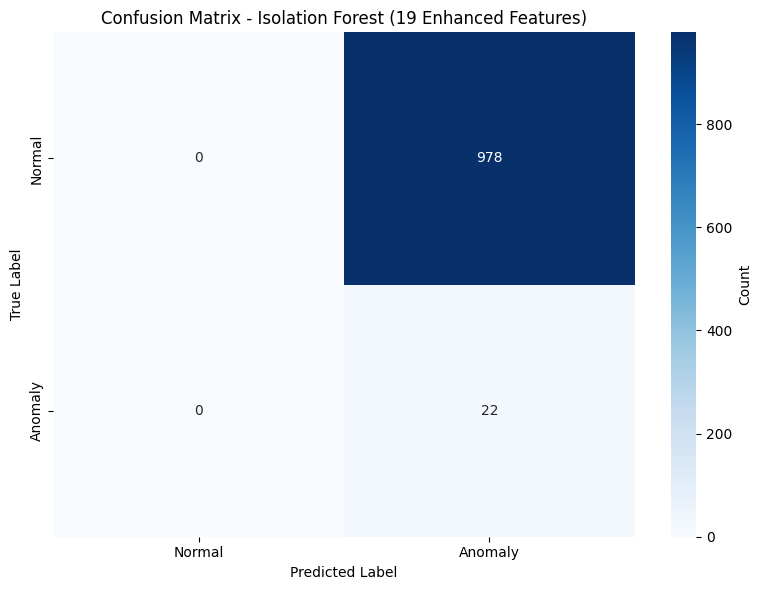


Confusion Matrix Summary:
True Negatives (Normal correctly identified):   0
False Positives (Normal incorrectly flagged):    978
False Negatives (Anomaly missed):                0
True Positives (Anomaly correctly identified):   22


In [81]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_anomaly)
tn, fp, fn, tp = cm.ravel()

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Isolation Forest (19 Enhanced Features)')
ax.set_xticklabels(['Normal', 'Anomaly'])
ax.set_yticklabels(['Normal', 'Anomaly'])
plt.tight_layout()
plt.show()

print('\nConfusion Matrix Summary:')
print(f'True Negatives (Normal correctly identified):   {tn}')
print(f'False Positives (Normal incorrectly flagged):    {fp}')
print(f'False Negatives (Anomaly missed):                {fn}')
print(f'True Positives (Anomaly correctly identified):   {tp}')

## Save model and reports

In [82]:
# Save artifacts
models_dir = Path('models')
reports_dir = Path('reports')
models_dir.mkdir(exist_ok=True)
reports_dir.mkdir(exist_ok=True)

model_path = models_dir / 'isolation_forest_banking.joblib'
joblib.dump(clf_pipeline, model_path)
print('Saved model to', model_path)

# Save all anomalies CSV (sorted by anomaly score)
all_anomalies = df_enriched[df_enriched['anomaly_flag'] == 1].sort_values('anomaly_score', ascending=False)
anomalies_csv = reports_dir / 'all_anomalies.csv'
# Select key columns for the report
report_cols = ['account_id', 'timestamp', 'amount', 'merchant', 'mcc', 'country', 'anomaly_score', 'anomaly_flag']
all_anomalies[report_cols].to_csv(anomalies_csv, index=False)
print(f'Saved {len(all_anomalies)} anomalies to {anomalies_csv}')

# Summary statistics
print(f'\n--- ANOMALY DETECTION SUMMARY ---')
print(f'Total transactions analyzed: {len(df_enriched)}')
print(f'Anomalies detected: {(df_enriched["anomaly_flag"] == 1).sum()}')
print(f'Normal transactions: {(df_enriched["anomaly_flag"] == 0).sum()}')
print(f'\nModel: Isolation Forest with {19} enhanced features')
print(f'Contamination parameter: 0.05 (5%)')
print(f'Score threshold: {df_enriched[df_enriched["anomaly_flag"] == 1]["anomaly_score"].min():.4f}')

Saved model to models\isolation_forest_banking.joblib
Saved 250 anomalies to reports\all_anomalies.csv

--- ANOMALY DETECTION SUMMARY ---
Total transactions analyzed: 5000
Anomalies detected: 250
Normal transactions: 4750

Model: Isolation Forest with 19 enhanced features
Contamination parameter: 0.05 (5%)
Score threshold: 0.0821


## Test Model with Custom/New Data

User can upload his custom data and get results

In [83]:
def preprocess_transactions(df_input):
    '''
    Apply same preprocessing as training data:
    - Log transform amount
    - Extract time features
    - Frequency encode categorical columns
    '''
    df_input = df_input.copy()
    
    # Amount log transform
    df_input['amount_log'] = np.log1p(df_input['amount'].astype(float))
    
    # Time features
    df_input['hour'] = df_input['timestamp'].dt.hour
    df_input['dayofweek'] = df_input['timestamp'].dt.dayofweek
    df_input['is_weekend'] = df_input['dayofweek'].isin([5,6]).astype(int)
    
    # Frequency encoding for categorical columns
    for col in ['merchant', 'mcc', 'country', 'state', 'channel']:
        freq = df_input[col].value_counts(dropna=True).to_dict()
        df_input[f'{col}_freq'] = df_input[col].map(freq).fillna(0).astype(int)
    
    return df_input

def load_test_data(file_path):
    '''
    Load test data and apply same preprocessing and feature engineering
    as training data to align with 19-feature enhanced model.
    '''
    try:
        df_new = pd.read_csv(file_path, parse_dates=['timestamp'])
        print(f'Loaded test data: {df_new.shape[0]} rows, {df_new.shape[1]} columns')
        
        # Apply same preprocessing as training data
        df_new = preprocess_transactions(df_new)
        
        # Load customer data and merge (same approach as training pipeline)
        df_customers = pd.read_csv(CUSTOMER_FILE_PATH)
        print(f'Loaded customer data: {df_customers.shape[0]} rows')
        
        # Merge customer features (same as training)
        customer_features = df_customers[['account_id', 'age', 'tenure_months', 'segment']].drop_duplicates(subset=['account_id'])
        df_new = df_new.merge(customer_features, on='account_id', how='left')
        
        # Derived customer features (same as training)
        df_new['new_account'] = (df_new['tenure_months'] < 6).astype(int)
        df_new['account_tenure_days'] = df_new['tenure_months'] * 30
        segment_risk_map = {'student': 3, 'retail': 1, 'smallbiz': 2, 'affluent': 0}
        df_new['segment_risk'] = df_new['segment'].map(segment_risk_map).fillna(1)
        df_new['age_young_flag'] = (df_new['age'] < 25).astype(int)
        df_new['age_elderly_flag'] = (df_new['age'] > 65).astype(int)
        
        # Behavioral features (same as training)
        txn_velocity = df_new.groupby('account_id').agg({
            'txn_id': 'count',
            'amount': ['mean', 'std', 'max'],
            'merchant': 'nunique'
        }).reset_index()
        txn_velocity.columns = ['account_id', 'txn_count', 'avg_amount', 'std_amount', 'max_amount', 'unique_merchants']
        txn_velocity['merchant_diversity'] = txn_velocity['unique_merchants'] / (txn_velocity['txn_count'] + 1)
        
        df_new = df_new.merge(txn_velocity[['account_id', 'avg_amount', 'unique_merchants', 'merchant_diversity']],
                              on='account_id', how='left')
        
        df_new['amount_deviation'] = (df_new['amount'] - df_new['avg_amount']).abs()
        df_new['amount_ratio'] = df_new['amount'] / (df_new['avg_amount'] + 1)
        
        df_new = df_new.fillna(0)
        
        print(f'Test data enriched with 19 features')
        return df_new
    
    except FileNotFoundError:
        print(f'Test file not found: {file_path}')
        return None

def score_test_data(df_test):
    '''
    Score test data using trained Isolation Forest model.
    Extracts 19 features and generates anomaly predictions.
    '''
    enhanced_features = [
        'amount_log', 'hour', 'dayofweek', 'is_weekend',
        'merchant_freq', 'mcc_freq', 'country_freq', 'state_freq', 'channel_freq',
        'new_account', 'account_tenure_days', 'segment_risk',
        'age_young_flag', 'age_elderly_flag', 'avg_amount', 'unique_merchants',
        'merchant_diversity', 'amount_deviation', 'amount_ratio'
    ]
    
    X_test_features = df_test[enhanced_features].astype(float).fillna(0)
    
    test_scores = -clf_pipeline.decision_function(X_test_features)
    test_predictions = clf_pipeline.named_steps['iforest'].predict(X_test_features)
    test_anomalies = (test_predictions == -1).astype(int)
    
    df_test['anomaly_score'] = test_scores
    df_test['anomaly_flag'] = test_anomalies
    
    print(f'Test data scored:')
    print(f'  - Total transactions: {len(df_test)}')
    print(f'  - Anomalies detected: {test_anomalies.sum()} ({100*test_anomalies.sum()/len(df_test):.1f}%)')
    print(f'  - Mean anomaly score: {test_scores.mean():.4f}')
    print(f'  - Max anomaly score: {test_scores.max():.4f}')
    
    return df_test


test_file = './Datasets/test_data_transactions.csv'
df_test = load_test_data(test_file)
if df_test is not None:
    df_test = score_test_data(df_test)
    df_test[['account_id', 'amount', 'anomaly_score', 'anomaly_flag']].to_csv(
        './reports/test_anomalies.csv', index=False
    )
    print('Test anomalies saved to ./reports/test_anomalies.csv')


Loaded test data: 12 rows, 12 columns
Loaded customer data: 300 rows
Test data enriched with 19 features
Test data scored:
  - Total transactions: 12
  - Anomalies detected: 3 (25.0%)
  - Mean anomaly score: 0.1070
  - Max anomaly score: 0.1418
Test anomalies saved to ./reports/test_anomalies.csv


## End of notebook